# 🚀 YOLOv8 Training Pipeline - Detección de Logos

## Objetivo
Este notebook entrena un modelo **YOLOv8** para detectar logos de empresas utilizando un dataset de más de 2000 imágenes descargado de Roboflow.

## Contenido
1. Verificación del entorno (GPU, librerías)
2. Exploración del dataset
3. Configuración de hiperparámetros
4. Entrenamiento del modelo
5. Evaluación y métricas
6. Inferencia de prueba
7. Exportación del modelo

## Requisitos
- GPU NVIDIA con soporte CUDA
- Dataset en formato YOLOv8 en `dataset_yolov8/`
- Contenedor Docker con PyTorch y Ultralytics instalados

---

## 1. 🔧 Verificación del Entorno

Primero comprobamos que el entorno tiene acceso a la GPU y que todas las librerías necesarias están instaladas correctamente.

In [1]:
# =============================================================================
# Environment Verification
# =============================================================================
# This cell checks that all required libraries are installed and that
# the GPU is accessible for training.
# =============================================================================

import sys
import torch
import ultralytics
from ultralytics import YOLO

# Print version information
print("="*60)
print("INFORMACIÓN DEL ENTORNO")
print("="*60)
print(f"Python versión: {sys.version}")
print(f"PyTorch versión: {torch.__version__}")
print(f"Ultralytics versión: {ultralytics.__version__}")
print("="*60)

# Check CUDA availability
# CUDA is NVIDIA's parallel computing platform that enables GPU acceleration
print(f"\nCUDA disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Nombre de GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"Versión CUDA: {torch.version.cuda}")
    print("\n✅ GPU lista para entrenamiento!")
else:
    print("\n⚠️ ADVERTENCIA: No se detectó GPU. El entrenamiento será muy lento.")

INFORMACIÓN DEL ENTORNO
Python versión: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
PyTorch versión: 2.1.0+cu118
Ultralytics versión: 8.0.196

CUDA disponible: True
Nombre de GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU
Memoria GPU total: 4.29 GB
Versión CUDA: 11.8

✅ GPU lista para entrenamiento!


## 2. 📁 Exploración del Dataset

Analizamos la estructura del dataset para entender cuántas imágenes tenemos y cuántas clases debemos detectar. El dataset está organizado en formato YOLOv8 con carpetas `train/`, `valid/` y `test/`.

In [2]:
# =============================================================================
# Dataset Structure Analysis
# =============================================================================
# This cell explores the dataset structure and counts the number of
# images in each split (train, validation, test).
# =============================================================================

import os
import yaml
from pathlib import Path

# Define dataset path relative to workspace
# When running in Docker, /workspace is mounted to the project root
DATASET_PATH = Path("/workspace/dataset_yolov8")

# Verify dataset exists
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"❌ Dataset no encontrado en: {DATASET_PATH}")

print("="*60)
print("ESTRUCTURA DEL DATASET")
print("="*60)

# Count images in each split
splits = ['train', 'valid', 'test']
total_images = 0

for split in splits:
    images_path = DATASET_PATH / split / 'images'
    if images_path.exists():
        # Count image files (common formats)
        image_count = len(list(images_path.glob('*.jpg'))) + \
                      len(list(images_path.glob('*.jpeg'))) + \
                      len(list(images_path.glob('*.png')))
        total_images += image_count
        print(f"📁 {split.upper():8} -> {image_count:5} imágenes")
    else:
        print(f"📁 {split.upper():8} -> No encontrado")

print(f"\n📊 TOTAL: {total_images} imágenes")

ESTRUCTURA DEL DATASET
📁 TRAIN    ->  2232 imágenes
📁 VALID    ->   402 imágenes
📁 TEST     ->   670 imágenes

📊 TOTAL: 3304 imágenes


### 2.1 Análisis del archivo data.yaml

El archivo `data.yaml` contiene la configuración del dataset, incluyendo las rutas a las imágenes y la lista de clases a detectar.

In [3]:
# =============================================================================
# Parse data.yaml Configuration
# =============================================================================
# The data.yaml file is essential for YOLO training as it defines:
# - train: path to training images
# - val: path to validation images
# - test: path to test images (optional)
# - nc: number of classes
# - names: list of class names
# =============================================================================

DATA_YAML_PATH = DATASET_PATH / 'data.yaml'

# Load and parse data.yaml
with open(DATA_YAML_PATH, 'r') as f:
    data_config = yaml.safe_load(f)

print("="*60)
print("CONFIGURACIÓN DEL DATASET (data.yaml)")
print("="*60)
print(f"Número de clases: {data_config.get('nc', 'No definido')}")
print(f"Ruta train: {data_config.get('train', 'No definido')}")
print(f"Ruta val: {data_config.get('val', 'No definido')}")
print(f"Ruta test: {data_config.get('test', 'No definido')}")

# Show first 10 classes as sample
class_names = data_config.get('names', [])
print(f"\nPrimeras 10 clases (de {len(class_names)} total):")
for i, name in enumerate(class_names[:10]):
    print(f"  {i:3}: {name}")
print("  ...")

CONFIGURACIÓN DEL DATASET (data.yaml)
Número de clases: 175
Ruta train: /workspace/dataset_yolov8/train/images
Ruta val: /workspace/dataset_yolov8/valid/images
Ruta test: /workspace/dataset_yolov8/test/images

Primeras 10 clases (de 175 total):
    0: ADP
    1: AOL
    2: ASB Bank Limited
    3: ATB Financial
    4: Absa Group
    5: Adobe
    6: Alaska USA Federal Credit Union
    7: Alibaba
    8: Allegro
    9: Amazon
  ...


### 2.2 Visualización de Imágenes de Ejemplo

Mostramos algunas imágenes de entrenamiento con sus anotaciones para verificar que el dataset está correctamente etiquetado.

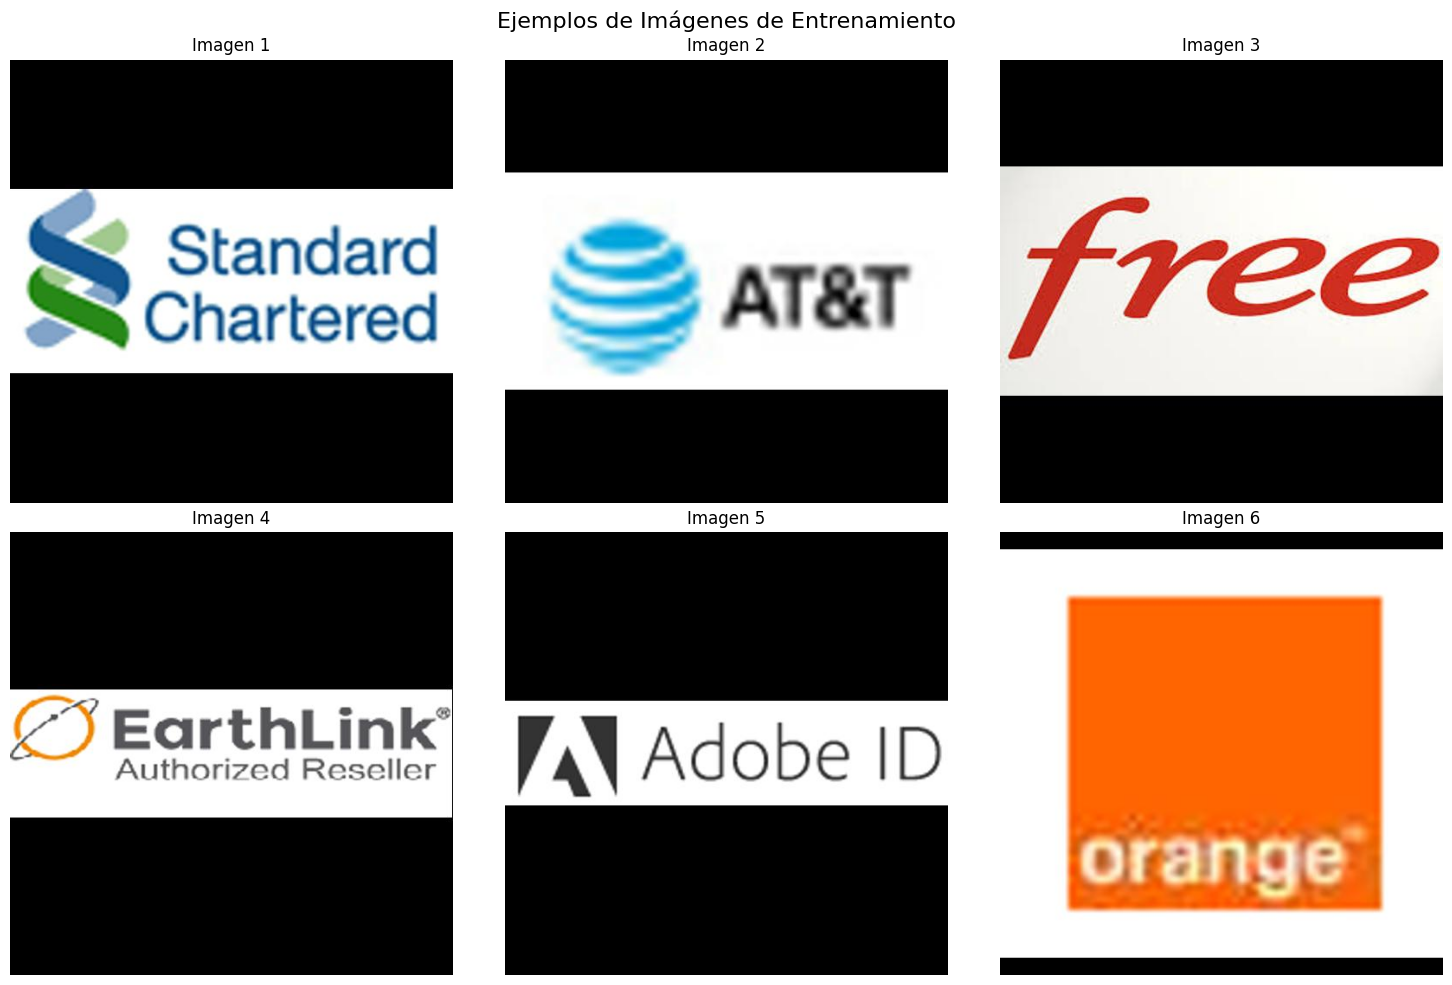


✅ Visualización completada


In [4]:
# =============================================================================
# Sample Image Visualization
# =============================================================================
# Display a grid of training images to visually inspect the dataset.
# This helps identify potential issues with images or annotations.
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Get list of training images
train_images_path = DATASET_PATH / 'train' / 'images'
image_files = list(train_images_path.glob('*.jpg')) + \
              list(train_images_path.glob('*.jpeg')) + \
              list(train_images_path.glob('*.png'))

# Select random samples
# random.seed(42) ensures reproducibility - same images each run
random.seed(42)
sample_images = random.sample(image_files, min(6, len(image_files)))

# Create visualization grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Ejemplos de Imágenes de Entrenamiento', fontsize=16)

for idx, (ax, img_path) in enumerate(zip(axes.flat, sample_images)):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(f'Imagen {idx + 1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Visualización completada")

## 3. ⚙️ Configuración de Hiperparámetros

Definimos los hiperparámetros para el entrenamiento. Estos valores están optimizados para una **RTX 3050 (4GB VRAM)**.

### Explicación de parámetros clave:

| Parámetro | Descripción |
|-----------|-------------|
| `epochs` | Número de veces que el modelo ve todo el dataset |
| `imgsz` | Tamaño al que se redimensionan las imágenes (mayor = más precisión pero más memoria) |
| `batch` | Número de imágenes procesadas a la vez (menor = menos memoria GPU) |
| `patience` | Épocas sin mejora antes de early stopping |
| `workers` | Procesos paralelos para cargar datos |
| `device` | GPU a usar (0 = primera GPU) |

In [5]:
# =============================================================================
# Training Hyperparameters Configuration
# =============================================================================
# These hyperparameters are optimized for RTX 3050 (4GB VRAM)
# Adjust based on your GPU memory availability
# =============================================================================

# -----------------------------------------------------------------------------
# Model Configuration
# -----------------------------------------------------------------------------
# MODEL_NAME: YOLOv8 variant to use as base model
#   - yolov8n: Nano (fastest, smallest, ~3.2M params)
#   - yolov8s: Small (~11.2M params)
#   - yolov8m: Medium (~25.9M params)
#   - yolov8l: Large (~43.7M params)
#   - yolov8x: Extra Large (most accurate, ~68.2M params)
# For 4GB VRAM, we recommend 'n' or 's' variants
# -----------------------------------------------------------------------------
MODEL_NAME = "yolov8n.pt"

# -----------------------------------------------------------------------------
# Training Parameters
# -----------------------------------------------------------------------------
# EPOCHS: Number of complete passes through the training dataset
#   - More epochs = better learning but risk of overfitting
#   - Recommended: 50-100 for logo detection
# -----------------------------------------------------------------------------
EPOCHS = 50

# -----------------------------------------------------------------------------
# IMAGE_SIZE: Input image resolution for training
#   - Larger = more detail captured but more GPU memory required
#   - Common values: 416, 512, 640, 1280
#   - For RTX 3050 4GB with batch=8: max recommended is 640
# -----------------------------------------------------------------------------
IMAGE_SIZE = 640

# -----------------------------------------------------------------------------
# BATCH_SIZE: Number of images processed together
#   - Larger batch = faster training, more stable gradients
#   - Smaller batch = less GPU memory required
#   - For RTX 3050 4GB with imgsz=640: recommended 4-8
#   - Use -1 for auto-batch (YOLO calculates optimal batch)
# -----------------------------------------------------------------------------
BATCH_SIZE = 8

# -----------------------------------------------------------------------------
# PATIENCE: Early stopping patience
#   - Training stops if no improvement for this many epochs
#   - Prevents overfitting and saves time
#   - Set to 0 to disable early stopping
# -----------------------------------------------------------------------------
PATIENCE = 15

# -----------------------------------------------------------------------------
# WORKERS: Number of dataloader workers
#   - Parallel processes that load data while GPU trains
#   - More workers = faster data loading (if CPU allows)
#   - Recommended: 2-4 for Windows, 4-8 for Linux
# -----------------------------------------------------------------------------
WORKERS = 4

# -----------------------------------------------------------------------------
# DEVICE: GPU device to use
#   - 0 = first GPU
#   - 'cpu' = use CPU only (very slow)
#   - '0,1' = use multiple GPUs
# -----------------------------------------------------------------------------
DEVICE = 0

# -----------------------------------------------------------------------------
# Experiment Naming
# -----------------------------------------------------------------------------
# EXPERIMENT_NAME: Name for this training run
#   - Results saved to runs/detect/{EXPERIMENT_NAME}/
# -----------------------------------------------------------------------------
EXPERIMENT_NAME = "logo_detection_v1"

# Path to data.yaml (using absolute path for container)
DATA_YAML = "/workspace/dataset_yolov8/data.yaml"

# Print configuration summary
print("="*60)
print("CONFIGURACIÓN DE ENTRENAMIENTO")
print("="*60)
print(f"Modelo base: {MODEL_NAME}")
print(f"Épocas: {EPOCHS}")
print(f"Tamaño imagen: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Early stopping patience: {PATIENCE}")
print(f"Workers: {WORKERS}")
print(f"Device: GPU {DEVICE}")
print(f"Nombre experimento: {EXPERIMENT_NAME}")
print(f"Data YAML: {DATA_YAML}")
print("="*60)

CONFIGURACIÓN DE ENTRENAMIENTO
Modelo base: yolov8n.pt
Épocas: 50
Tamaño imagen: 640x640
Batch size: 8
Early stopping patience: 15
Workers: 4
Device: GPU 0
Nombre experimento: logo_detection_v1
Data YAML: /workspace/dataset_yolov8/data.yaml


## 4. 🏋️ Entrenamiento del Modelo

Iniciamos el entrenamiento del modelo YOLOv8. El proceso puede tardar varias horas dependiendo del número de épocas y el tamaño del dataset.

### Durante el entrenamiento:
- Se muestra el progreso de cada época
- Se guarda automáticamente el mejor modelo (`best.pt`) y el último (`last.pt`)
- Se generan gráficas de métricas en `runs/detect/{nombre}/`

In [6]:
# =============================================================================
# Model Loading
# =============================================================================
# Load the pretrained YOLOv8 model that will be fine-tuned
# on our custom dataset. Using a pretrained model (transfer learning)
# significantly improves training speed and final accuracy.
# =============================================================================

from ultralytics import YOLO

# Load pretrained model
# This downloads the model weights if not already cached
print("Cargando modelo preentrenado...")
model = YOLO(MODEL_NAME)
print(f"\n✅ Modelo {MODEL_NAME} cargado correctamente")

# Display model architecture summary
print("\n" + "="*60)
print("RESUMEN DEL MODELO")
print("="*60)
model.info()

Cargando modelo preentrenado...


YOLOv8n summary: 225 layers, 3157200 parameters, 0 gradients, 8.9 GFLOPs



✅ Modelo yolov8n.pt cargado correctamente

RESUMEN DEL MODELO


(225, 3157200, 0, 8.8575488)

In [7]:
# =============================================================================
# Training Execution
# =============================================================================
# This cell runs the actual training loop. The model.train() method
# handles everything: data loading, forward/backward passes, optimization,
# checkpointing, and logging.
#
# Key training parameters explained:
# - data: Path to dataset configuration (data.yaml)
# - epochs: Total training epochs
# - imgsz: Input image size (images resized to this)
# - batch: Batch size (-1 for auto-batch)
# - patience: Early stopping trigger
# - save: Save checkpoints
# - save_period: Save checkpoint every N epochs (-1 = only best/last)
# - cache: Cache images for faster training (False for large datasets)
# - device: GPU device ID
# - workers: Dataloader worker processes
# - project: Parent directory for results
# - name: Experiment name (subdirectory)
# - exist_ok: OK if experiment directory exists
# - pretrained: Use pretrained weights
# - optimizer: Optimizer algorithm (SGD, Adam, AdamW)
# - verbose: Print detailed logs
# - seed: Random seed for reproducibility
# - val: Run validation during training
# - plots: Generate training plots
# =============================================================================

import time

print("="*60)
print("🚀 INICIANDO ENTRENAMIENTO")
print("="*60)
print(f"⏱️  Inicio: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("\nEsto puede tardar varias horas. Puedes observar el progreso abajo.")
print("="*60 + "\n")

# Start training timer
start_time = time.time()

# Execute training
results = model.train(
    # Dataset configuration
    data=DATA_YAML,
    
    # Training duration
    epochs=EPOCHS,
    patience=PATIENCE,
    
    # Image and batch settings
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    
    # Hardware settings
    device=DEVICE,
    workers=WORKERS,
    
    # Saving settings
    save=True,
    save_period=-1,  # Only save best and last
    
    # Caching (set False for large datasets to avoid RAM issues)
    cache=False,
    
    # Output settings
    project="/workspace/runs/detect",
    name=EXPERIMENT_NAME,
    exist_ok=True,  # OK to overwrite if exists
    
    # Model settings
    pretrained=True,
    
    # Optimizer: AdamW often works better than SGD for fine-tuning
    optimizer="AdamW",
    
    # Learning rate (auto-scaled based on batch size)
    lr0=0.01,  # Initial learning rate
    lrf=0.01,  # Final learning rate (fraction of lr0)
    
    # Logging and visualization
    verbose=True,
    plots=True,
    
    # Reproducibility
    seed=42,
    
    # Validation settings
    val=True,
)

# Calculate training time
training_time = time.time() - start_time
hours = int(training_time // 3600)
minutes = int((training_time % 3600) // 60)
seconds = int(training_time % 60)

print("\n" + "="*60)
print("✅ ENTRENAMIENTO COMPLETADO")
print("="*60)
print(f"⏱️  Tiempo total: {hours}h {minutes}m {seconds}s")
print(f"📁 Resultados guardados en: /workspace/runs/detect/{EXPERIMENT_NAME}/")

New https://pypi.org/project/ultralytics/8.4.9 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 4GB Laptop GPU, 4096MiB)


🚀 INICIANDO ENTRENAMIENTO
⏱️  Inicio: 2026-01-30 00:47:38

Esto puede tardar varias horas. Puedes observar el progreso abajo.



engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/workspace/dataset_yolov8/data.yaml, epochs=50, patience=15, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=4, project=/workspace/runs/detect, name=logo_detection_v1, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, stream_buffer=False, line_width=None, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=True, format=torchscript, keras=False, optimize=False, int8=False, dynamic=False, simplify=Fals


✅ ENTRENAMIENTO COMPLETADO
⏱️  Tiempo total: 2h 42m 20s
📁 Resultados guardados en: /workspace/runs/detect/logo_detection_v1/


## 5. 📊 Evaluación y Métricas

Analizamos los resultados del entrenamiento. Las métricas principales son:

| Métrica | Descripción |
|---------|-------------|
| **mAP50** | Mean Average Precision con IoU=0.50 (métrica principal) |
| **mAP50-95** | mAP promediada para IoU de 0.50 a 0.95 (más estricta) |
| **Precision** | % de detecciones correctas sobre total de detecciones |
| **Recall** | % de objetos detectados sobre total de objetos reales |

In [8]:
# =============================================================================
# Training Results Analysis
# =============================================================================
# After training, we analyze the results saved in the experiment directory.
# This includes metrics, loss curves, and confusion matrix.
# =============================================================================

from pathlib import Path
import pandas as pd

# Path to training results
RESULTS_PATH = Path(f"/workspace/runs/detect/{EXPERIMENT_NAME}")

# Load training results CSV
results_csv = RESULTS_PATH / "results.csv"

if results_csv.exists():
    # Read and display results
    df_results = pd.read_csv(results_csv)
    df_results.columns = df_results.columns.str.strip()  # Clean column names
    
    print("="*60)
    print("MÉTRICAS FINALES DEL ENTRENAMIENTO")
    print("="*60)
    
    # Get last epoch metrics
    last_row = df_results.iloc[-1]
    
    # Display key metrics
    print(f"\n📈 Época final: {int(last_row['epoch']) + 1}")
    print(f"\n🎯 MÉTRICAS DE DETECCIÓN:")
    print(f"   - mAP@0.50:      {last_row.get('metrics/mAP50(B)', 'N/A'):.4f}")
    print(f"   - mAP@0.50-0.95: {last_row.get('metrics/mAP50-95(B)', 'N/A'):.4f}")
    print(f"   - Precision:     {last_row.get('metrics/precision(B)', 'N/A'):.4f}")
    print(f"   - Recall:        {last_row.get('metrics/recall(B)', 'N/A'):.4f}")
    
    print(f"\n📉 PÉRDIDAS (menores = mejor):")
    print(f"   - Box Loss:      {last_row.get('train/box_loss', 'N/A'):.4f}")
    print(f"   - Class Loss:    {last_row.get('train/cls_loss', 'N/A'):.4f}")
    print(f"   - DFL Loss:      {last_row.get('train/dfl_loss', 'N/A'):.4f}")
    
else:
    print("⚠️ No se encontró el archivo results.csv")
    print("El entrenamiento podría no haber completado correctamente.")

MÉTRICAS FINALES DEL ENTRENAMIENTO

📈 Época final: 51

🎯 MÉTRICAS DE DETECCIÓN:
   - mAP@0.50:      0.2807
   - mAP@0.50-0.95: 0.2718
   - Precision:     0.3589
   - Recall:        0.3315

📉 PÉRDIDAS (menores = mejor):
   - Box Loss:      0.1300
   - Class Loss:    1.8805
   - DFL Loss:      0.8973


### 5.1 Visualización de Curvas de Entrenamiento

Mostramos las curvas de pérdida y métricas generadas durante el entrenamiento para evaluar la convergencia del modelo.

📊 Curvas de Entrenamiento:


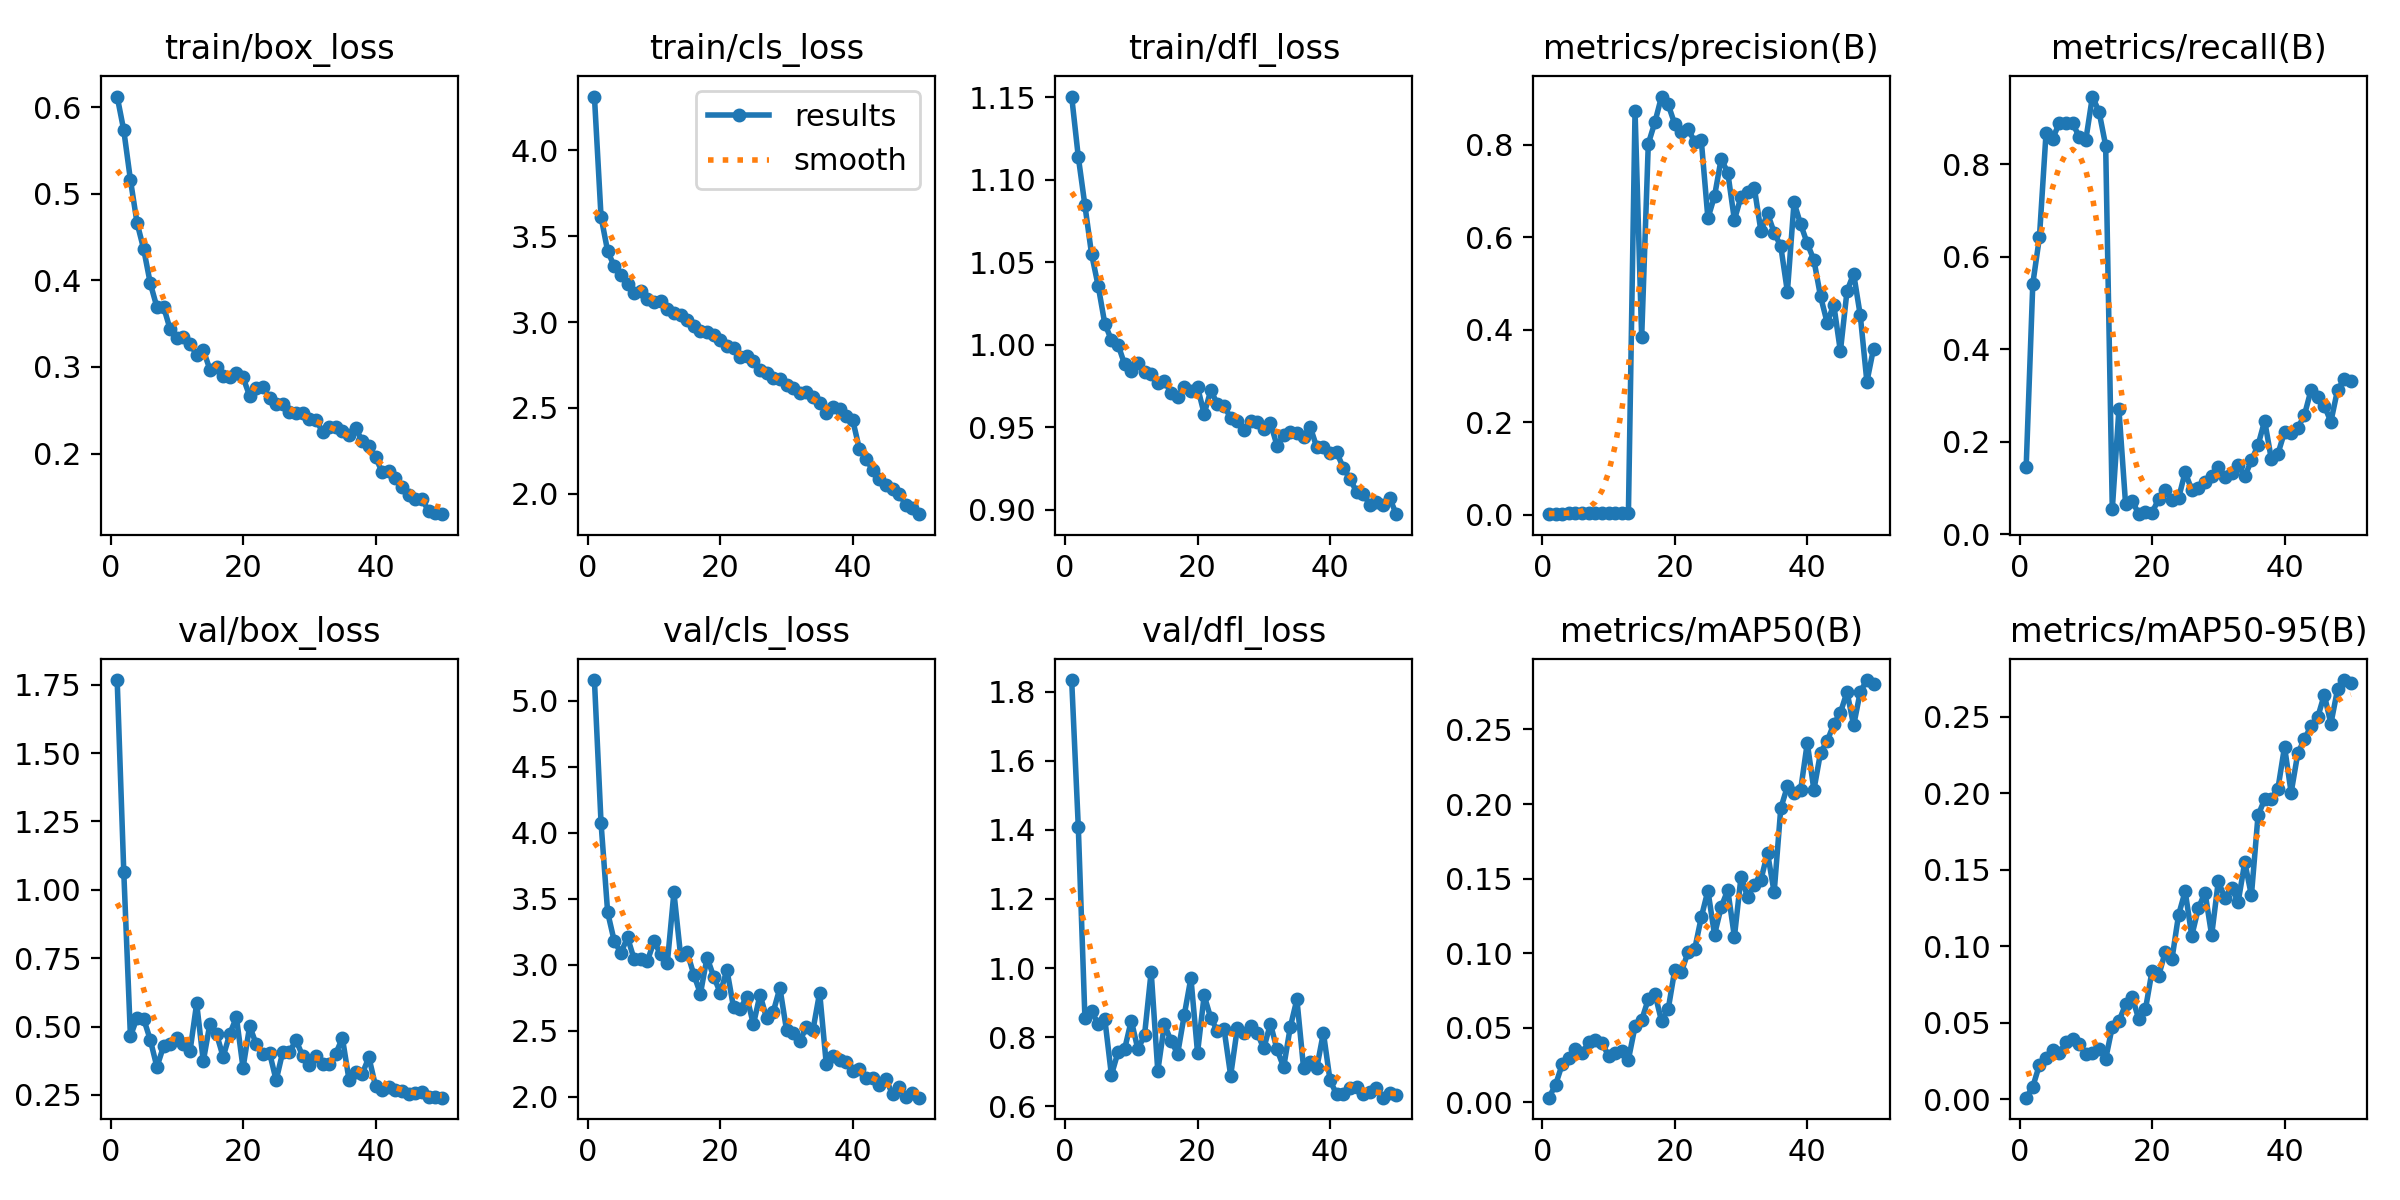


📊 Matriz de Confusión:


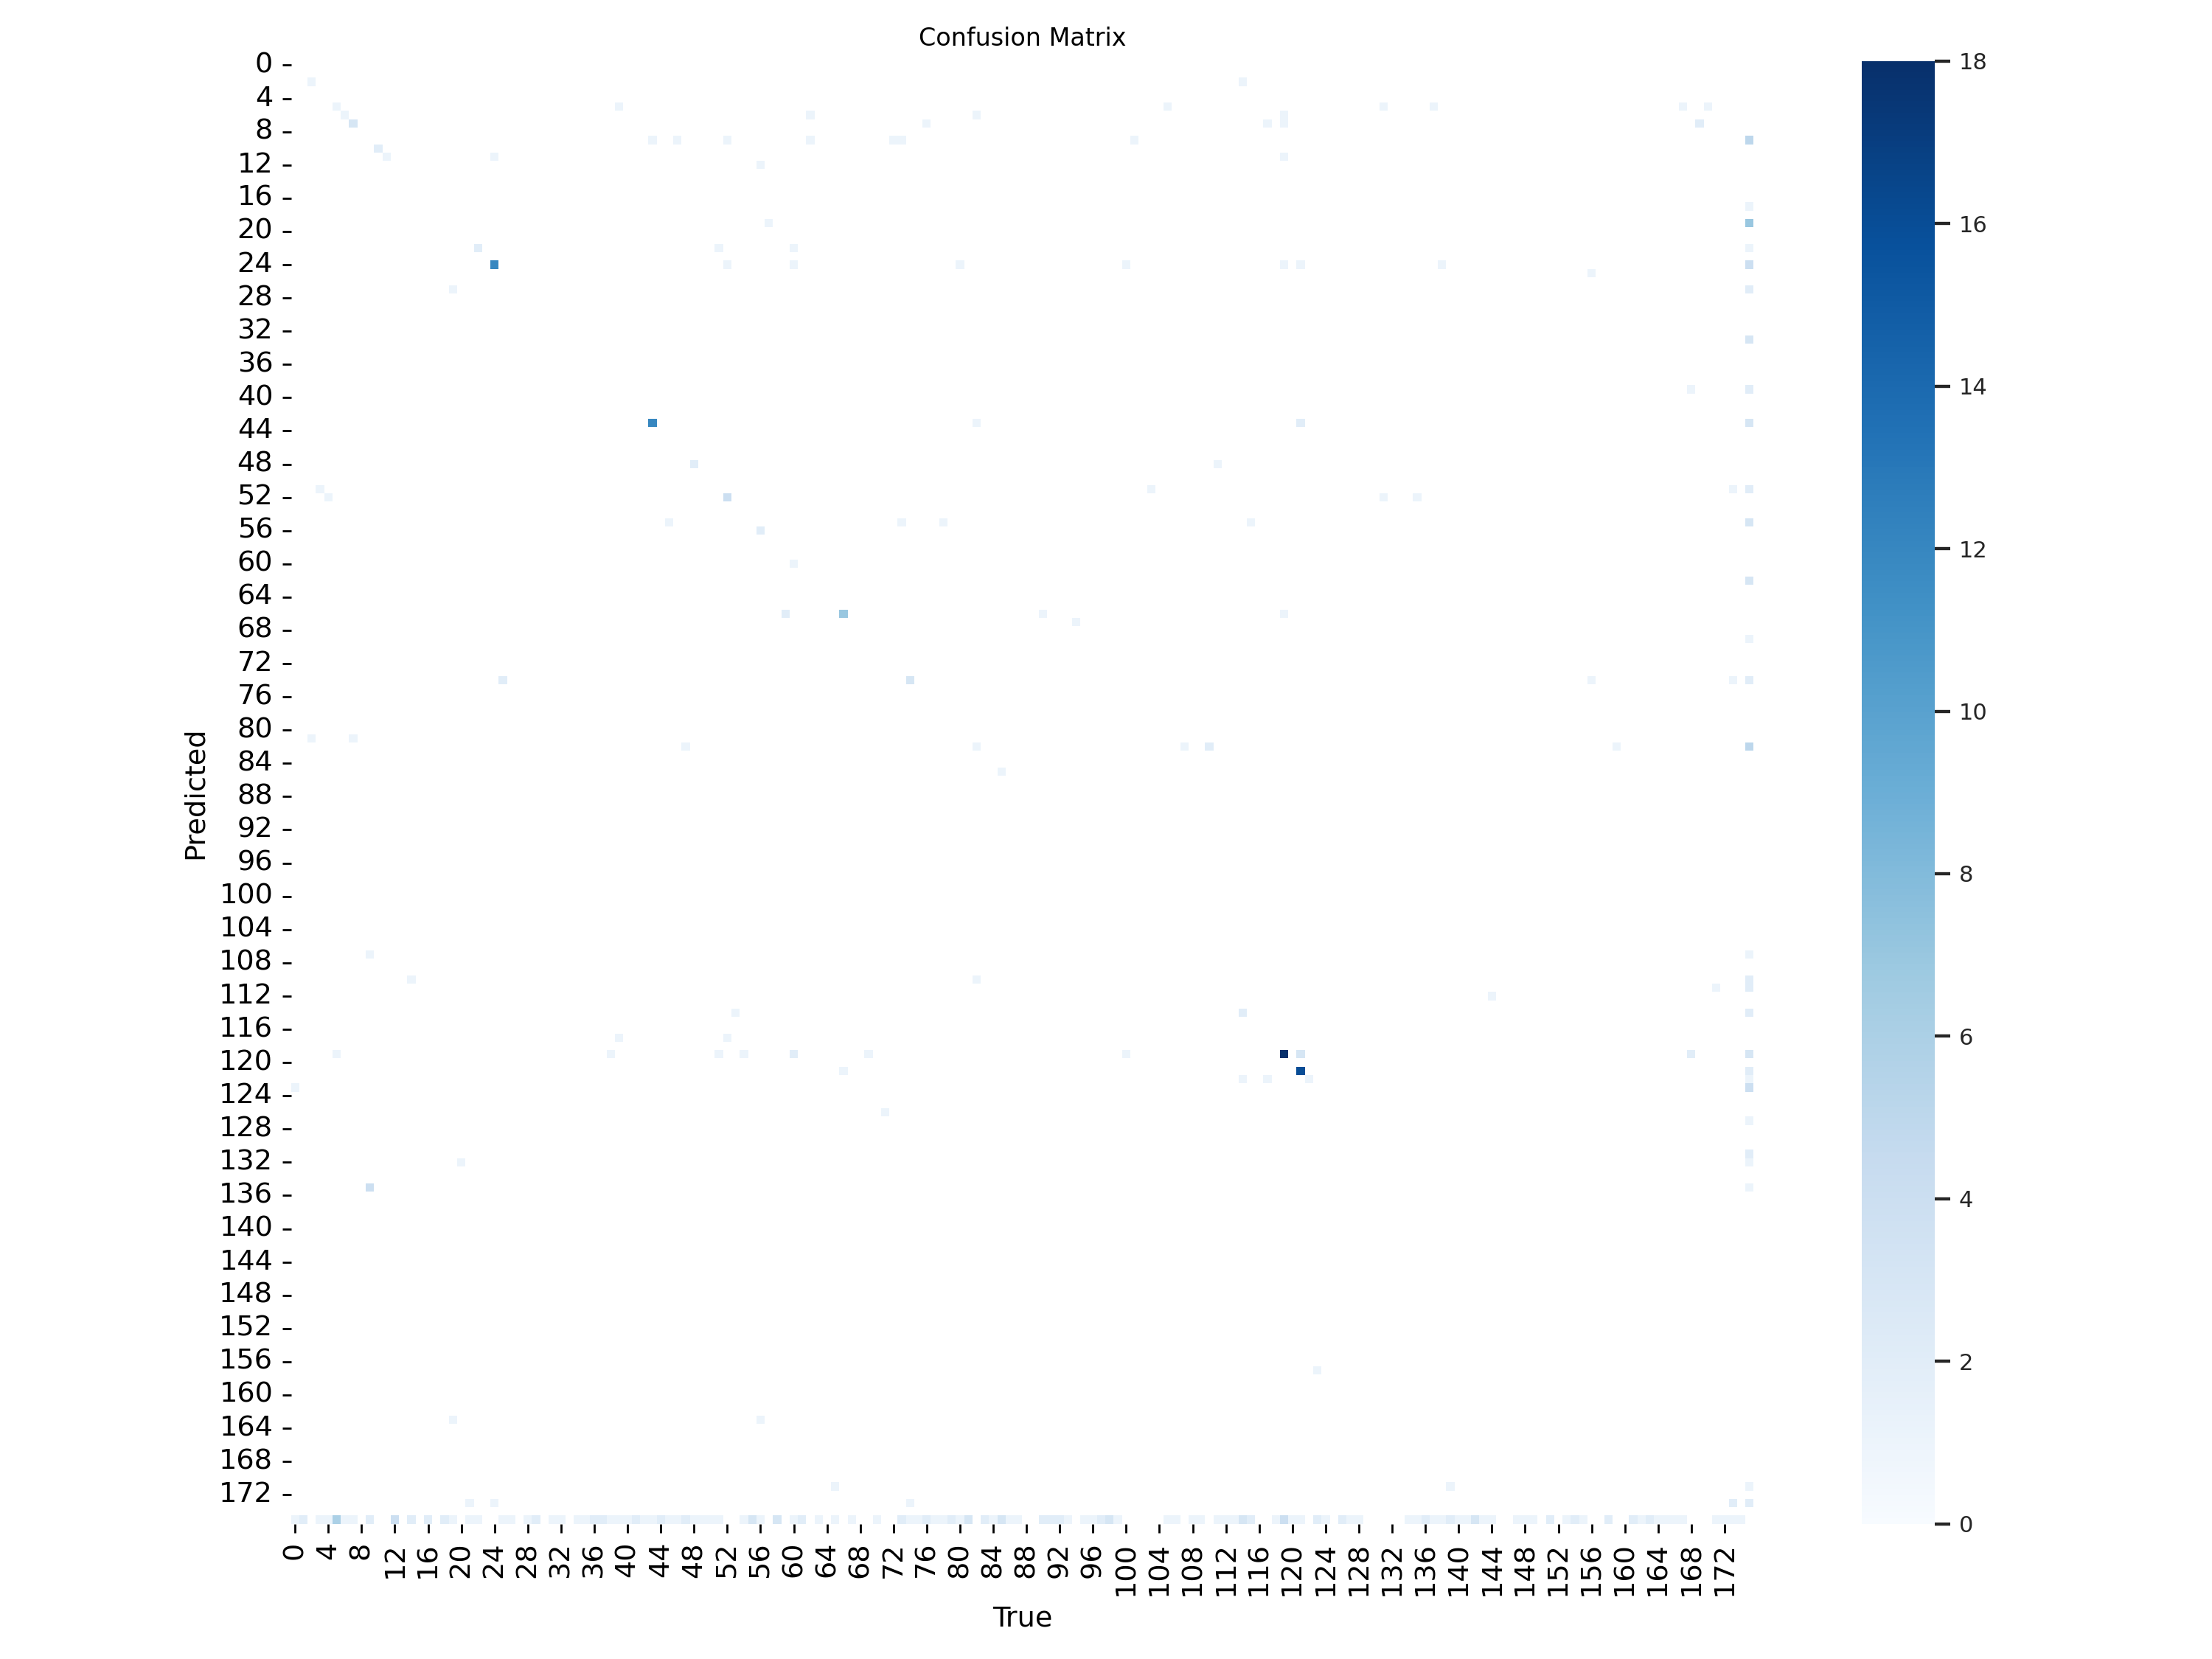

In [9]:
# =============================================================================
# Training Curves Visualization
# =============================================================================
# Display the training plots generated by YOLO:
# - results.png: All metrics in one image
# - confusion_matrix.png: Class predictions vs ground truth
# =============================================================================

from IPython.display import Image, display
from pathlib import Path

RESULTS_PATH = Path(f"/workspace/runs/detect/{EXPERIMENT_NAME}")

# Display training results plot
results_plot = RESULTS_PATH / "results.png"
if results_plot.exists():
    print("📊 Curvas de Entrenamiento:")
    display(Image(filename=str(results_plot), width=1000))
else:
    print("⚠️ No se encontró results.png")

# Display confusion matrix
confusion_matrix = RESULTS_PATH / "confusion_matrix.png"
if confusion_matrix.exists():
    print("\n📊 Matriz de Confusión:")
    display(Image(filename=str(confusion_matrix), width=800))
else:
    print("\n⚠️ No se encontró confusion_matrix.png")

### 5.2 Validación del Modelo

Ejecutamos la validación sobre el conjunto de validación para obtener métricas detalladas por clase.

In [10]:
# =============================================================================
# Model Validation
# =============================================================================
# Run validation on the validation set to get detailed metrics.
# We load the best model (not last) for validation.
# =============================================================================

from ultralytics import YOLO

# Path to best model weights
BEST_MODEL_PATH = f"/workspace/runs/detect/{EXPERIMENT_NAME}/weights/best.pt"

print("="*60)
print("VALIDACIÓN DEL MODELO")
print("="*60)
print(f"\nCargando mejor modelo desde: {BEST_MODEL_PATH}")

# Load the best trained model
best_model = YOLO(BEST_MODEL_PATH)

# Run validation
# This evaluates the model on the validation set defined in data.yaml
print("\nEjecutando validación...")
metrics = best_model.val(
    data=DATA_YAML,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    plots=True,  # Generate validation plots
    verbose=True
)

print("\n" + "="*60)
print("RESUMEN DE VALIDACIÓN")
print("="*60)
print(f"mAP@0.50:      {metrics.box.map50:.4f}")
print(f"mAP@0.50-0.95: {metrics.box.map:.4f}")
print(f"Precision:     {metrics.box.mp:.4f}")
print(f"Recall:        {metrics.box.mr:.4f}")

VALIDACIÓN DEL MODELO

Cargando mejor modelo desde: /workspace/runs/detect/logo_detection_v1/weights/best.pt


Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 4GB Laptop GPU, 4096MiB)



Ejecutando validación...


Model summary (fused): 168 layers, 3363449 parameters, 0 gradients, 9.7 GFLOPs
val: Scanning /workspace/dataset_yolov8/valid/labels.cache... 402 images, 25 backgrounds, 0 corrupt: 100% 402/402 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 51/51 [00:08<00:00,  5.87it/s]
                   all        402        377       0.28      0.339      0.283      0.274
                   ADP        402          2          0          0     0.0433      0.037
                   AOL        402          2          1          0      0.186     0.0823
      ASB Bank Limited        402          2     0.0933        0.5      0.497      0.448
         ATB Financial        402          2          0          0      0.126      0.126
            Absa Group        402          2          0          0     0.0304     0.0304
                 Adobe        402          8      0.189      0.625      0.259      0.245
Alaska USA Federal Credit Union        40


RESUMEN DE VALIDACIÓN
mAP@0.50:      0.2827
mAP@0.50-0.95: 0.2737
Precision:     0.2799
Recall:        0.3390


## 6. 🔍 Inferencia de Prueba

Probamos el modelo entrenado con imágenes del conjunto de test para visualizar las detecciones.

In [11]:
# =============================================================================
# Inference on Test Images
# =============================================================================
# Run the trained model on test images to visualize predictions.
# Results are saved to runs/detect/predict/
# =============================================================================

from ultralytics import YOLO
import random
from pathlib import Path

# Load the best model
BEST_MODEL_PATH = f"/workspace/runs/detect/{EXPERIMENT_NAME}/weights/best.pt"
model = YOLO(BEST_MODEL_PATH)

# Get test images
test_images_path = Path("/workspace/dataset_yolov8/test/images")
test_images = list(test_images_path.glob('*.jpg')) + \
              list(test_images_path.glob('*.jpeg')) + \
              list(test_images_path.glob('*.png'))

# Select random samples for inference
random.seed(42)
sample_images = random.sample(test_images, min(10, len(test_images)))

print("="*60)
print("INFERENCIA EN IMÁGENES DE TEST")
print("="*60)
print(f"\nProcesando {len(sample_images)} imágenes de prueba...")

# Run inference
# conf: Minimum confidence threshold for detections
# iou: IoU threshold for Non-Maximum Suppression
# save: Save annotated images
results = model.predict(
    source=sample_images,
    conf=0.5,  # Confidence threshold (0.5 = 50% confidence minimum)
    iou=0.45,  # IoU threshold for NMS (filters overlapping boxes)
    save=True,
    save_txt=False,
    project="/workspace/runs/detect",
    name="inference_test",
    exist_ok=True
)

print(f"\n✅ Inferencia completada")
print(f"📁 Imágenes guardadas en: /workspace/runs/detect/inference_test/")

INFERENCIA EN IMÁGENES DE TEST

Procesando 10 imágenes de prueba...



0: 640x640 1 Chase Personal Banking, 1: 640x640 (no detections), 2: 640x640 1 DHL, 3: 640x640 (no detections), 4: 640x640 (no detections), 5: 640x640 (no detections), 6: 640x640 (no detections), 7: 640x640 (no detections), 8: 640x640 (no detections), 9: 640x640 (no detections), 315.0ms
Speed: 11.0ms preprocess, 31.5ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /workspace/runs/detect/inference_test



✅ Inferencia completada
📁 Imágenes guardadas en: /workspace/runs/detect/inference_test/


### 6.1 Visualización de Predicciones

Mostramos las imágenes con las detecciones realizadas por el modelo.

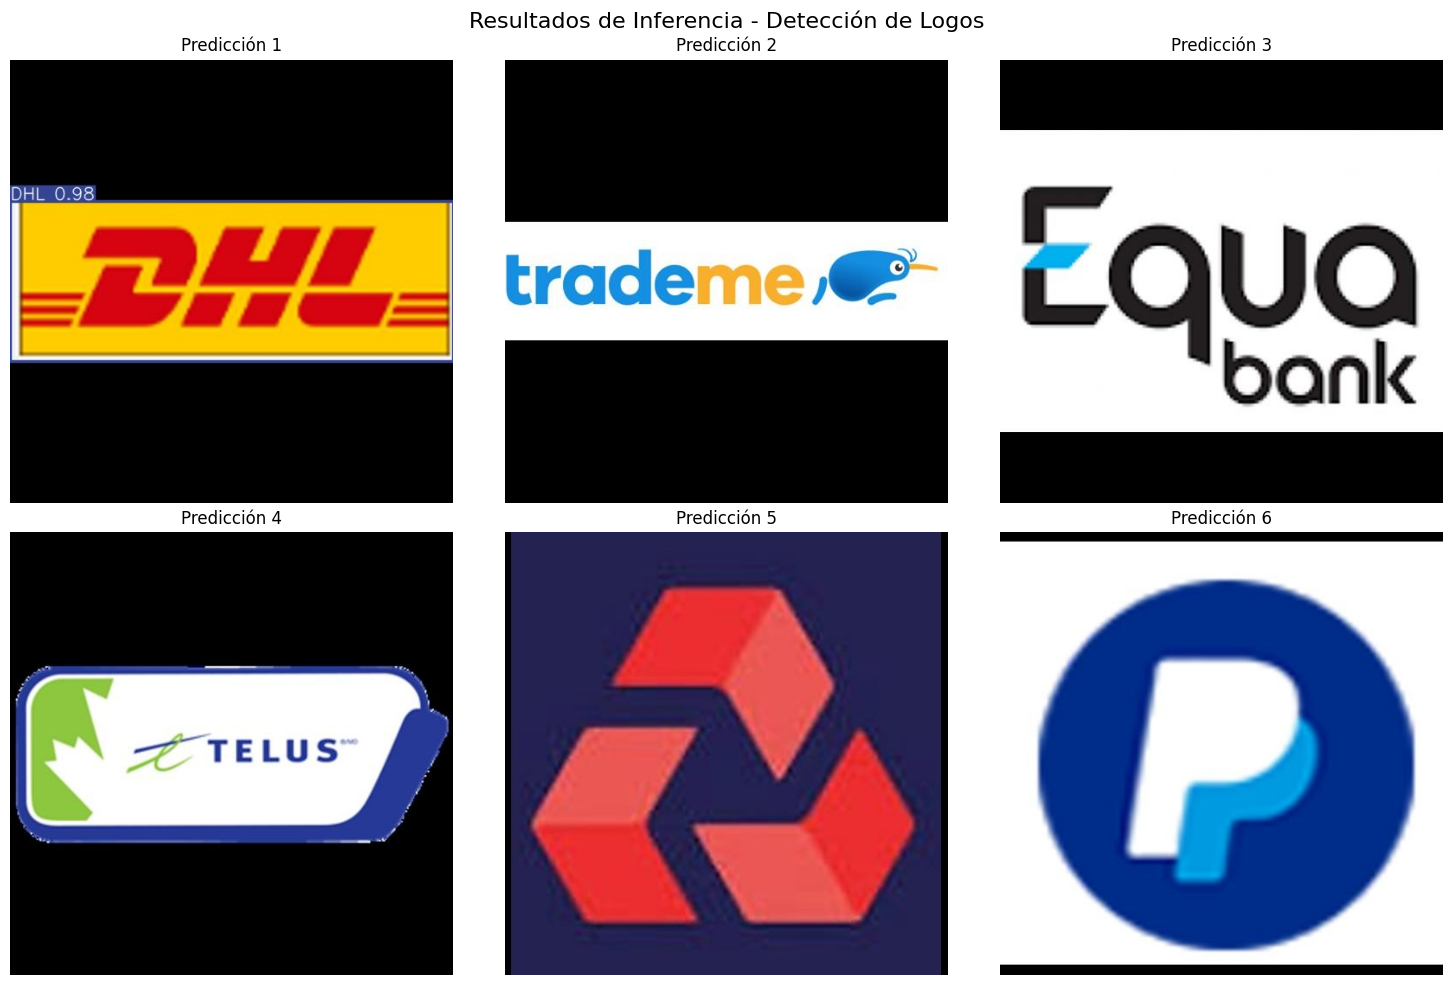

In [12]:
# =============================================================================
# Display Inference Results
# =============================================================================
# Show the annotated images with detected bounding boxes and labels.
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Path to inference results
inference_path = Path("/workspace/runs/detect/inference_test")

# Get all result images
result_images = list(inference_path.glob('*.jpg')) + \
                list(inference_path.glob('*.jpeg')) + \
                list(inference_path.glob('*.png'))

if result_images:
    # Display up to 6 images
    display_images = result_images[:6]
    
    # Calculate grid size
    n_images = len(display_images)
    cols = 3
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    fig.suptitle('Resultados de Inferencia - Detección de Logos', fontsize=16)
    
    # Flatten axes for easy iteration
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    else:
        axes = axes.flat
    
    for idx, (ax, img_path) in enumerate(zip(axes, display_images)):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f'Predicción {idx + 1}')
        ax.axis('off')
    
    # Hide empty subplots
    for ax in list(axes)[n_images:]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No se encontraron imágenes de inferencia.")

## 7. 💾 Exportación del Modelo

Exportamos el modelo entrenado en diferentes formatos para su uso en producción:

| Formato | Uso |
|---------|-----|
| **PyTorch (.pt)** | Uso general con Python |
| **ONNX** | Interoperabilidad entre frameworks |
| **TensorRT** | Inferencia optimizada en NVIDIA GPUs |

In [14]:
# =============================================================================
# Model Export
# =============================================================================
# Export the trained model to different formats for deployment.
# The best.pt model is already in PyTorch format.
# Here we export to ONNX for broader compatibility.
# =============================================================================

from ultralytics import YOLO
import shutil
from pathlib import Path

# Paths
BEST_MODEL_PATH = f"/workspace/runs/detect/{EXPERIMENT_NAME}/weights/best.pt"
MODELS_DIR = Path("/workspace/models")
MODELS_DIR.mkdir(exist_ok=True)

print("="*60)
print("EXPORTACIÓN DEL MODELO")
print("="*60)

# Load best model
model = YOLO(BEST_MODEL_PATH)

# Copy best.pt to models directory
dest_pt = MODELS_DIR / "best.pt"
shutil.copy(BEST_MODEL_PATH, dest_pt)
print(f"\n✅ Modelo PyTorch copiado a: {dest_pt}")

# Export to ONNX format
# ONNX is an open format for machine learning models
# It allows running the model with ONNX Runtime, TensorRT, etc.
print("\n📦 Exportando a formato ONNX...")
onnx_path = model.export(
    format='onnx',
    imgsz=IMAGE_SIZE,
    simplify=True,  # Simplify ONNX graph for faster inference
    dynamic=False,  # Fixed input size
)
print(f"✅ Modelo ONNX exportado a: {onnx_path}")

# Copy ONNX to models directory
if onnx_path:
    onnx_dest = MODELS_DIR / "best.onnx"
    shutil.copy(onnx_path, onnx_dest)
    print(f"✅ Modelo ONNX copiado a: {onnx_dest}")

print("\n" + "="*60)
print("MODELOS EXPORTADOS")
print("="*60)
print(f"\n📁 Directorio de modelos: {MODELS_DIR}")
for model_file in MODELS_DIR.glob('*'):
    size_mb = model_file.stat().st_size / (1024 * 1024)
    print(f"   - {model_file.name}: {size_mb:.2f} MB")

EXPORTACIÓN DEL MODELO

✅ Modelo PyTorch copiado a: /workspace/models/best.pt

📦 Exportando a formato ONNX...


Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.1.0+cu118 CPU (13th Gen Intel Core(TM) i7-1360P)
Model summary (fused): 168 layers, 3363449 parameters, 0 gradients, 9.7 GFLOPs

PyTorch: starting from '/workspace/runs/detect/logo_detection_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 179, 8400) (6.7 MB)

ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: simplifying with onnxsim 0.4.36...
ONNX: export success ✅ 1.2s, saved as '/workspace/runs/detect/logo_detection_v1/weights/best.onnx' (13.0 MB)

Export complete (3.0s)
Results saved to /workspace/runs/detect/logo_detection_v1/weights
Predict:         yolo predict task=detect model=/workspace/runs/detect/logo_detection_v1/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/workspace/runs/detect/logo_detection_v1/weights/best.onnx imgsz=640 data=/workspace/dataset_yolov8/data.yaml  
Visualize:       https://netron.app


✅ Modelo ONNX exportado a: /workspace/runs/detect/logo_detection_v1/weights/best.onnx
✅ Modelo ONNX copiado a: /workspace/models/best.onnx

MODELOS EXPORTADOS

📁 Directorio de modelos: /workspace/models
   - best.onnx: 12.99 MB
   - best.pt: 6.65 MB
   - metadata.json: 0.00 MB


## 8. 📝 Resumen del Experimento

Resumen final del entrenamiento realizado y próximos pasos.

In [15]:
# =============================================================================
# Experiment Summary
# =============================================================================
# Generate a summary of the training experiment for documentation.
# =============================================================================

import pandas as pd
from pathlib import Path
from datetime import datetime

print("="*70)
print("                    RESUMEN DEL EXPERIMENTO                         ")
print("="*70)

print(f"""
📅 Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

🔧 CONFIGURACIÓN:
   - Modelo base: {MODEL_NAME}
   - Épocas configuradas: {EPOCHS}
   - Tamaño de imagen: {IMAGE_SIZE}x{IMAGE_SIZE}
   - Batch size: {BATCH_SIZE}
   - Early stopping patience: {PATIENCE}
   - Optimizer: AdamW

📊 DATASET:
   - Número de clases: {len(class_names)}
   - Imágenes de entrenamiento: ~2232
   - Imágenes de validación: ~402
   - Imágenes de test: ~670

📁 ARCHIVOS GENERADOS:
   - Modelo entrenado: /workspace/runs/detect/{EXPERIMENT_NAME}/weights/best.pt
   - Modelo exportado: /workspace/models/best.pt
   - Modelo ONNX: /workspace/models/best.onnx
   - Métricas: /workspace/runs/detect/{EXPERIMENT_NAME}/results.csv
   - Gráficas: /workspace/runs/detect/{EXPERIMENT_NAME}/results.png

📝 PRÓXIMOS PASOS:
   1. Revisar las métricas y curvas de entrenamiento
   2. Analizar la matriz de confusión para clases problemáticas
   3. Considerar aumentar épocas si el modelo no converge
   4. Probar con modelos más grandes (yolov8s, yolov8m) si se necesita más precisión
   5. Implementar data augmentation avanzado si hay overfitting
   6. Integrar el modelo exportado en el backend de la aplicación
""")

print("="*70)
print("              ✅ ENTRENAMIENTO FINALIZADO CON ÉXITO                 ")
print("="*70)

                    RESUMEN DEL EXPERIMENTO                         

📅 Fecha: 2026-01-30 07:29:03

🔧 CONFIGURACIÓN:
   - Modelo base: yolov8n.pt
   - Épocas configuradas: 50
   - Tamaño de imagen: 640x640
   - Batch size: 8
   - Early stopping patience: 15
   - Optimizer: AdamW

📊 DATASET:
   - Número de clases: 175
   - Imágenes de entrenamiento: ~2232
   - Imágenes de validación: ~402
   - Imágenes de test: ~670

📁 ARCHIVOS GENERADOS:
   - Modelo entrenado: /workspace/runs/detect/logo_detection_v1/weights/best.pt
   - Modelo exportado: /workspace/models/best.pt
   - Modelo ONNX: /workspace/models/best.onnx
   - Métricas: /workspace/runs/detect/logo_detection_v1/results.csv
   - Gráficas: /workspace/runs/detect/logo_detection_v1/results.png

📝 PRÓXIMOS PASOS:
   1. Revisar las métricas y curvas de entrenamiento
   2. Analizar la matriz de confusión para clases problemáticas
   3. Considerar aumentar épocas si el modelo no converge
   4. Probar con modelos más grandes (yolov8s, yolov8